# WP5 · Build B — the population weight field

`docs/maup_sensitivity_and_spatial_cv_plan.md` §3.1 asks for a **population-weighted** climate
exposure table as a drop-in twin of the existing area-weighted Build A, so the two diff cleanly and
the question *"does exposure construction alone change the decision?"* can be answered.

A weighted mean is `Σ wᵢ xᵢ`. Build A and Build B differ **only in `w`** — the climate fields `x`
are identical. So the whole of Build B is the weight field, and it can be built, inspected and
frozen **before a single hour of ERA5-Land is downloaded**. Once the grids land, the exposure table
is a lookup against these weights.

That matters here because the climate grids are the one input still off this machine. The weights
are not: WorldPop and the DEM were staged locally by the M6 notebooks, so this notebook runs today.

### What this notebook answers

1. Where does population actually sit inside each district, relative to the areal centre?
2. How much spatial support does population-weighting throw away? (an effective-sample question)
3. What does Build A's `all_touched` cell mask include that a fractional-overlap mask would not?
4. **How large a shift in exposure should Build B produce, and where?** — answered quantitatively
   using the staged DEM and a lapse rate, before any climate data exists to confirm it.

Question 4 is the point. If the answer were "a hundredth of a degree", WP5's honest-null clause
(plan §3.4) would fire early and cheaply. It is not.

### Scope

Sri Lanka only. Build A's own aggregation is not re-run or modified — it is frozen
(`docs/exposure_freeze_v1.md`, SHA256 `3900082b…`, 10,842 rows = 417 ISO weeks × 26 RDHS) and this
notebook only characterises what a different weighting would do to it.

## 1 · Setup, and assert the frame

In [1]:
import json, hashlib, gzip, shutil, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.features
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name.startswith("notebooks") else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"          # WorldPop + DEM staged by notebooks 01/03
QUAR = REPO / "data_quarantine" / "wp5_exposure"
QUAR.mkdir(parents=True, exist_ok=True)
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
rdhs = gpd.read_file(GEOM)
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_geom == prov0["geometry_sha256_16"], "geometry differs from the M6 frame — stop"

SEED = prov0["seed"]
CRS_EA = prov0["crs_equal_area"]
N_UNITS = len(rdhs)

print("frame        :", N_UNITS, "RDHS | geometry sha", sha_geom)
print("equal-area   :", CRS_EA[:52], "...")
print("staged inputs:", len(list((M6 / 'dem').glob('*.tif'))), "DEM tiles,",
      len(list((M6 / 'worldpop').glob('*.tif'))), "WorldPop years")
print("output dir   :", QUAR)

frame        : 26 RDHS | geometry sha 9e5e2c0a541ecac1
equal-area   : +proj=laea +lat_0=7.6221 +lon_0=80.6987 +x_0=0 +y_0= ...
staged inputs: 12 DEM tiles, 3 WorldPop years
output dir   : /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/data_quarantine/wp5_exposure


## 2 · Configuration

`LAPSE_RATE` is the standard environmental rate the plan's §3.1b names (−6.5 °C/km). It is used
here only to convert an elevation displacement into the temperature units a reader can judge — it
is not a correction being applied to anything yet. Build C is where it becomes a method.

In [2]:
POP_YEAR = 2020                 # newest WorldPop UN-adj vintage staged; see section 11
LAPSE_RATE = 6.5 / 1000         # degC per metre, standard environmental lapse rate

# climate grid definitions. `edge0` is a CELL EDGE, not a cell centre — see section 3.
GRIDS = {
    "chirps_p05": dict(res=0.05, edge_lon=-180.0, edge_lat=50.0,  verified=False,
                       product="CHIRPS v2.0 daily p05", var="precipitation"),
    "era5land":   dict(res=0.10, edge_lon=-180.05, edge_lat=90.05, verified=False,
                       product="ERA5-Land hourly 0.1 deg", var="t2m / d2m"),
}

CHIRPS_PROBE = ("https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/tifs/p05/"
                "2019/chirps-v2.0.2019.06.15.tif.gz")

print("population vintage:", POP_YEAR)
print("lapse rate        :", LAPSE_RATE * 1000, "degC / km")
for k, g in GRIDS.items():
    print(f"{k:<12} {g['res']}deg  {g['product']}")

population vintage: 2020
lapse rate        : 6.5 degC / km
chirps_p05   0.05deg  CHIRPS v2.0 daily p05
era5land     0.1deg  ERA5-Land hourly 0.1 deg


## 3 · The two climate grids, and a half-cell trap

Weighting means asking *which climate cell does this person live in*, so the cell boundaries have to
be right. Both products are regular lat/lon grids, but they place their edges differently:

- **CHIRPS** is distributed as a GeoTIFF whose transform states the upper-left **edge**. Nothing to
  assume — read it off a real file.
- **ERA5-Land** is distributed on grid *points* at exact multiples of 0.1°. A point is a cell
  **centre**, so the edges fall on 0.05°, 0.15°, … — offset half a cell from the CHIRPS convention.

Getting that offset wrong moves every person up to ~5.5 km into the wrong cell. It would not raise
an error and the resulting weights would look entirely reasonable, so CHIRPS is **verified against
a real granule** and ERA5-Land's convention is declared explicitly and left flagged
`verified=False` until a granule exists to check it against.

In [3]:
probe = QUAR / "chirps_probe.tif"
if not probe.exists():
    gz = QUAR / "chirps_probe.tif.gz"
    urllib.request.urlretrieve(CHIRPS_PROBE, gz)
    with gzip.open(gz, "rb") as f, open(probe, "wb") as g:
        shutil.copyfileobj(f, g)
    gz.unlink()

with rasterio.open(probe) as s:
    print("CHIRPS granule :", s.shape, "| res", round(s.res[0], 6))
    print("  upper-left edge:", s.transform.c, s.transform.f)
    print("  nodata tag     :", s.nodata, "  <- absent; -9999 must be masked explicitly at build time")
    assert np.isclose(s.transform.c, GRIDS["chirps_p05"]["edge_lon"])
    assert np.isclose(s.transform.f, GRIDS["chirps_p05"]["edge_lat"])
    assert np.isclose(s.res[0], GRIDS["chirps_p05"]["res"], atol=1e-6)

GRIDS["chirps_p05"]["verified"] = True
print("\nCHIRPS grid definition verified against a real granule")
print("ERA5-Land grid definition is DECLARED, not verified — assert it when a granule lands:")
print("  centres on multiples of 0.1 deg  ->  edges at -180.05 + 0.1k")

CHIRPS granule : (2000, 7200) | res 0.05
  upper-left edge: -180.0 50.0
  nodata tag     : None   <- absent; -9999 must be masked explicitly at build time

CHIRPS grid definition verified against a real granule
ERA5-Land grid definition is DECLARED, not verified — assert it when a granule lands:
  centres on multiples of 0.1 deg  ->  edges at -180.05 + 0.1k


In [4]:
def cell_ij(lon, lat, g):
    """Cell (row, col) on grid `g` for point(s) at lon/lat. Edges from g['edge_lon'/'edge_lat']."""
    ci = np.floor((lon - g["edge_lon"]) / g["res"]).astype(np.int32)
    ri = np.floor((g["edge_lat"] - lat) / g["res"]).astype(np.int32)
    return ri, ci


# sanity: a point at an ERA5-Land grid POINT must sit at the CENTRE of its cell, not on an edge
g = GRIDS["era5land"]
ri, ci = cell_ij(np.array([80.0]), np.array([7.0]), g)
west = g["edge_lon"] + ci * g["res"]
north = g["edge_lat"] - ri * g["res"]
print(f"ERA5-Land point (80.0, 7.0) lands in cell spanning "
      f"lon {west[0]:.2f}..{west[0]+g['res']:.2f}, lat {north[0]-g['res']:.2f}..{north[0]:.2f}")
print(f"  offset from cell centre: {abs(80.0 - (west[0] + g['res']/2)):.4f} deg (must be 0)")
assert np.isclose(80.0, west[0] + g["res"] / 2) and np.isclose(7.0, north[0] - g["res"] / 2)
print("  half-cell convention correct")

ERA5-Land point (80.0, 7.0) lands in cell spanning lon 79.95..80.05, lat 6.95..7.05
  offset from cell centre: 0.0000 deg (must be 0)
  half-cell convention correct


## 4 · WorldPop — the weights themselves

In [5]:
wp_path = M6 / "worldpop" / f"lka_ppp_{POP_YEAR}_UNadj.tif"
with rasterio.open(wp_path) as src:
    pop = src.read(1).astype(np.float64)
    T, (H, W), NODATA = src.transform, src.shape, src.nodata
pop[pop == NODATA] = 0.0

lon_c = T.c + (np.arange(W) + 0.5) * T.a          # pixel centres
lat_c = T.f + (np.arange(H) + 0.5) * T.e

print(f"WorldPop {POP_YEAR}: {H} x {W} @ {T.a:.6f} deg (~{T.a*111e3:.0f} m)")
print(f"  extent    : lon {lon_c.min():.3f}..{lon_c.max():.3f}  lat {lat_c.min():.3f}..{lat_c.max():.3f}")
print(f"  raster tot: {pop.sum()/1e6:.3f} M people")

WorldPop 2020: 4700 x 2676 @ 0.000833 deg (~92 m)
  extent    : lon 79.648..81.877  lat 5.919..9.835
  raster tot: 21.413 M people


Rasterise the districts onto that same grid, so every 100 m pixel carries a district id. The
capture fraction is the known coastal shortfall (notebook 03 §7): pixels go whole to the unit
containing their centre, and Sri Lanka is all coastline. Report it, don't absorb it — WP5's own
denominator is this same quantity.

In [6]:
dist = rasterio.features.rasterize(
    [(g, i + 1) for i, g in enumerate(rdhs.geometry)],
    out_shape=(H, W), transform=T, fill=0, dtype="int32")

inside = dist > 0
print(f"pixels inside districts: {inside.sum():,} of {H*W:,}")
print(f"population captured    : {pop[inside].sum()/1e6:.3f} M of {pop.sum()/1e6:.3f} M "
      f"({100*pop[inside].sum()/pop.sum():.2f}%)")
print(f"outside the 26 units   : {(pop.sum()-pop[inside].sum())/1e3:.0f} thousand people")

pixels inside districts: 7,793,861 of 12,577,200
population captured    : 21.121 M of 21.413 M (98.63%)
outside the 26 units   : 292 thousand people


Area weights need a cosine-of-latitude factor: a 0.000833° pixel is a *degree* box, so its true
ground area shrinks toward the poles. Sri Lanka spans only ~4° so the effect is small, but it is
free to do correctly and matches the convention notebook 03 established.

In [7]:
coslat = np.broadcast_to(np.cos(np.deg2rad(lat_c))[:, None], (H, W))
print(f"cos(lat) across the island: {coslat[inside].min():.4f} .. {coslat[inside].max():.4f} "
      f"({100*(coslat[inside].max()/coslat[inside].min()-1):.2f}% span)")

cos(lat) across the island: 0.9853 .. 0.9947 (0.95% span)


## 5 · Assign every person to a climate cell

One pass per grid: each 100 m pixel gets a `(district, cell)` key, then population and area are
summed within each key. A 100 m pixel is 55× finer than a CHIRPS cell and 110× finer than an
ERA5-Land one, so assigning pixels whole to cells — rather than splitting them across cell
boundaries — costs far less than the WorldPop discretisation already in the input.

In [8]:
d_in, p_in, a_in = dist[inside], pop[inside], coslat[inside]
LON = np.broadcast_to(lon_c[None, :], (H, W))[inside]
LAT = np.broadcast_to(lat_c[:, None], (H, W))[inside]

weights = {}
for name, g in GRIDS.items():
    ri, ci = cell_ij(LON, LAT, g)
    key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
    uniq, inv = np.unique(key, return_inverse=True)

    w = pd.DataFrame({
        "unit": (uniq // 10**10).astype(int),
        "cell_row": ((uniq % 10**10) // 10**5).astype(int),
        "cell_col": (uniq % 10**5).astype(int),
        "pop_sum": np.bincount(inv, weights=p_in),
        "area": np.bincount(inv, weights=a_in),
        "lon": np.bincount(inv, weights=LON * p_in.clip(min=0) + 0) / np.maximum(np.bincount(inv), 1),
    })
    w["rdhs_name"] = rdhs.rdhs_name.values[w.unit - 1]
    w["geometry_id"] = rdhs.geometry_id.values[w.unit - 1]
    weights[name] = w

    print(f"{name:<12} (district, cell) pairs: {len(w):>6,} | distinct cells: "
          f"{w.groupby(['cell_row','cell_col']).ngroups:>6,} | "
          f"cells shared across districts: {len(w) - w.groupby(['cell_row','cell_col']).ngroups:>5,}")

chirps_p05   (district, cell) pairs:  3,044 | distinct cells:  2,355 | cells shared across districts:   689


era5land     (district, cell) pairs:    965 | distinct cells:    627 | cells shared across districts:   338


In [9]:
for name, w in weights.items():
    n = w.groupby("rdhs_name").size()
    print(f"{name:<12} cells per district: min {n.min():>3}  median {int(n.median()):>3}  max {n.max():>3}")

chirps_p05   cells per district: min  39  median 101  max 287
era5land     cells per district: min  14  median  34  max  85


## 6 · The weight field

Normalise within each district. `w_area` reproduces what Build A does (up to its mask, §7);
`w_pop` is Build B. Everything downstream is a contrast between these two columns.

In [10]:
for name, w in weights.items():
    w["w_area"] = w.groupby("unit")["area"].transform(lambda s: s / s.sum())
    w["w_pop"] = w.groupby("unit")["pop_sum"].transform(lambda s: s / s.sum())
    assert np.allclose(w.groupby("unit")["w_area"].sum(), 1)
    assert np.allclose(w.groupby("unit")["w_pop"].sum(), 1)

w = weights["era5land"]
print("era5land weight field, Colombo:")
print(w[w.rdhs_name == "Colombo"][["cell_row", "cell_col", "pop_sum", "w_area", "w_pop"]]
      .sort_values("w_pop", ascending=False).head(8).round(4).to_string(index=False))

era5land weight field, Colombo:
 cell_row  cell_col     pop_sum  w_area  w_pop
      831      2599 964896.2146  0.1689 0.4085
      832      2599 489577.6239  0.1289 0.2073
      831      2600 286415.1327  0.1508 0.1213
      832      2600 238405.2319  0.1302 0.1009
      830      2599 120853.4596  0.0127 0.0512
      831      2601 105431.6408  0.1468 0.0446
      832      2601  55889.1318  0.0864 0.0237
      831      2602  38574.2318  0.0830 0.0163


The gap between the two columns is the entire mechanism of Build B. Where a district's people are
spread evenly the columns agree; where they concentrate, one cell can carry most of the exposure.

points above the line: cells that carry more people than land; below: the reverse


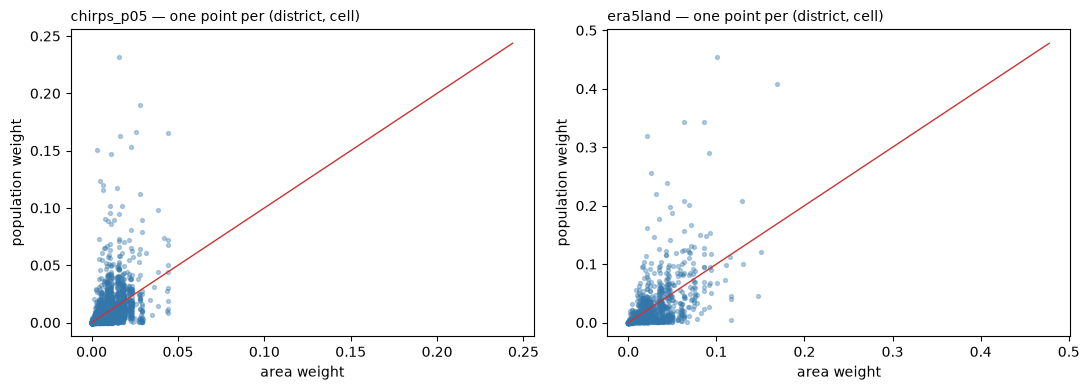

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, w) in zip(axes, weights.items()):
    ax.scatter(w.w_area, w.w_pop, s=8, alpha=.35, color="#37a")
    lim = max(w.w_area.max(), w.w_pop.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#c33", lw=1)
    ax.set_xlabel("area weight"); ax.set_ylabel("population weight")
    ax.set_title(f"{name} — one point per (district, cell)", loc="left", fontsize=10)
plt.tight_layout()
print("points above the line: cells that carry more people than land; below: the reverse")

## 7 · What Build A's mask includes

Build A aggregated with *"precomputed per-RDHS cell masks"* (`docs/exposure_freeze_v1.md` §8), the
`all_touched` style the plan §3.1 explicitly moves away from: a cell counts if the polygon touches
it **at all**, however little of the district it holds. Fractional overlap weights it by how much.

The cost is not that `all_touched` adds cells — it is that it adds them at **full weight**. A cell
clipping 3% of a district counts exactly as much as one wholly inside it.

Two measures, neither of which needs an arbitrary cut-off. `cell_frac` is how much of each *cell*
falls in the district, so a coastal cell that is mostly ocean scores low. And the total-variation
distance between the uniform (`all_touched`) and fractional weight vectors says what share of a
district's weight sits in the wrong place.

In [12]:
rows = []
for name, g in GRIDS.items():
    # total pixels per cell, over the whole raster — the denominator for cell_frac
    ri_all, ci_all = cell_ij(np.broadcast_to(lon_c[None, :], (H, W)),
                             np.broadcast_to(lat_c[:, None], (H, W)), g)
    kall = ri_all.astype(np.int64) * 10**5 + ci_all
    cells_u, cells_n = np.unique(kall, return_counts=True)
    total_of = dict(zip(cells_u.tolist(), cells_n.tolist()))

    w = weights[name]
    ck = w.cell_row.values.astype(np.int64) * 10**5 + w.cell_col.values
    npix = w.groupby(["unit", "cell_row", "cell_col"]).size()          # 1 row per pair already
    # pixels of THIS district in the cell = area weight numerator in pixel units
    ri, ci = cell_ij(LON, LAT, g)
    key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
    uniq, cnt = np.unique(key, return_counts=True)
    pix = pd.Series(cnt, index=uniq)
    w = w.assign(px=pix.reindex(w.unit.values.astype(np.int64) * 10**10 + ck).values,
                 cell_px=[total_of.get(int(k), 0) for k in ck])
    w["cell_frac"] = w.px / w.cell_px

    for unit in range(1, N_UNITS + 1):
        d = w[w.unit == unit]
        w_uniform = np.full(len(d), 1 / len(d))
        tvd = 0.5 * np.abs(w_uniform - d.w_area.values).sum()
        rows.append(dict(grid=name, rdhs=rdhs.rdhs_name.iloc[unit - 1], n_cells=len(d),
                         median_cell_frac=float(d.cell_frac.median()),
                         frac_cells_under_25pct=float((d.cell_frac < .25).mean()),
                         weight_misplaced=float(tvd)))
    weights[name] = w

mask_cost = pd.DataFrame(rows)
print(mask_cost.groupby("grid")[["n_cells", "median_cell_frac",
                                 "frac_cells_under_25pct", "weight_misplaced"]]
      .median().round(3).to_string())
print("\n`weight_misplaced` = total-variation distance between an all_touched (uniform) weighting")
print("and the fractional one: the share of the district's weight sitting on the wrong cells.")
print("\nworst districts (ERA5-Land):")
print(mask_cost[mask_cost.grid == "era5land"].nlargest(5, "weight_misplaced").round(3).to_string(index=False))

            n_cells  median_cell_frac  frac_cells_under_25pct  weight_misplaced
grid                                                                           
chirps_p05    101.5             0.912                   0.196             0.241
era5land       34.5             0.511                   0.287             0.308

`weight_misplaced` = total-variation distance between an all_touched (uniform) weighting
and the fractional one: the share of the district's weight sitting on the wrong cells.

worst districts (ERA5-Land):
    grid       rdhs  n_cells  median_cell_frac  frac_cells_under_25pct  weight_misplaced
era5land   Kalmunai       21             0.425                   0.333             0.401
era5land    Colombo       14             0.323                   0.500             0.395
era5land     Jaffna       25             0.230                   0.520             0.361
era5land    Kegalle       26             0.663                   0.423             0.359
era5land Batticaloa       41

## 8 · Where the people actually are

The physical driver of any A→B difference is **displacement**: how far the population-weighted
centre of a district sits from its area-weighted centre. For a spatially smooth field, the shift in
the weighted mean is approximately the field's gradient times this displacement — so displacement
in kilometres is the honest predictor of how much Build B can possibly move.

In [13]:
ea = rdhs.to_crs(CRS_EA)
X = np.zeros((H, W)); Y = np.zeros((H, W))
pts = gpd.GeoSeries(gpd.points_from_xy(LON, LAT), crs="EPSG:4326").to_crs(CRS_EA)
px, py = pts.x.values, pts.y.values          # metres, equal-area

disp = []
for unit in range(1, N_UNITS + 1):
    k = d_in == unit
    xa, ya = np.average(px[k], weights=a_in[k]), np.average(py[k], weights=a_in[k])
    xp, yp = np.average(px[k], weights=p_in[k]), np.average(py[k], weights=p_in[k])
    disp.append(dict(rdhs=rdhs.rdhs_name.iloc[unit - 1],
                     dx_km=(xp - xa) / 1e3, dy_km=(yp - ya) / 1e3,
                     dist_km=np.hypot(xp - xa, yp - ya) / 1e3))
disp = pd.DataFrame(disp).sort_values("dist_km", ascending=False)

print("displacement of the population centre from the areal centre:\n")
print(disp.head(8).round(2).to_string(index=False))
print(f"\nmedian {disp.dist_km.median():.1f} km | max {disp.dist_km.max():.1f} km "
      f"({disp.iloc[0].rdhs})")
print(f"ERA5-Land cell is ~{0.1*111:.0f} km across; CHIRPS ~{0.05*111:.0f} km.")

displacement of the population centre from the areal centre:

        rdhs  dx_km  dy_km  dist_km
    Puttalam  -5.93 -28.88    29.49
  Hambantota -19.58  -8.64    21.40
  Batticaloa  17.31  -7.09    18.71
      Mannar -13.74   6.37    15.15
    Kalmunai   3.83  14.33    14.84
      Ampara  -1.74  13.36    13.47
  Mullaitivu  11.58   2.92    11.95
Anuradhapura  -2.33 -11.02    11.27

median 9.1 km | max 29.5 km (Puttalam)
ERA5-Land cell is ~11 km across; CHIRPS ~6 km.


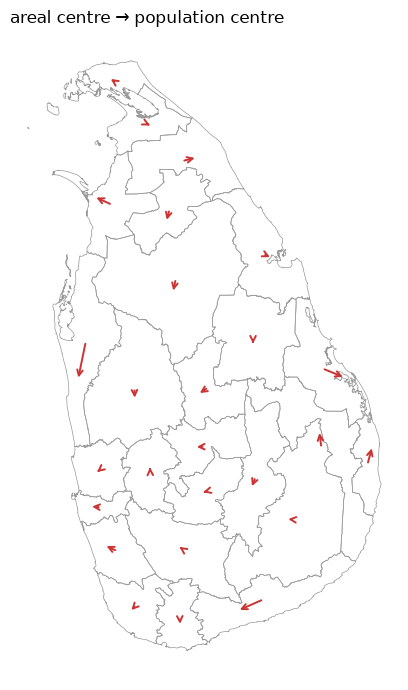

In [14]:
fig, ax = plt.subplots(figsize=(5.6, 7))
ea.boundary.plot(ax=ax, color="#999", lw=.5)
for unit in range(1, N_UNITS + 1):
    k = d_in == unit
    xa, ya = np.average(px[k], weights=a_in[k]), np.average(py[k], weights=a_in[k])
    xp, yp = np.average(px[k], weights=p_in[k]), np.average(py[k], weights=p_in[k])
    ax.annotate("", xy=(xp, yp), xytext=(xa, ya),
                arrowprops=dict(arrowstyle="->", color="#c33", lw=1.4))
ax.set_axis_off()
ax.set_title("areal centre → population centre", loc="left")
plt.tight_layout()

## 9 · How much spatial support survives

Population-weighting concentrates weight, which means the exposure for a district is effectively
sampled from fewer climate cells than the area-weighted version. The **effective number of cells**,
`1 / Σ wᵢ²`, puts a number on it. This is not a defect of Build B — it is the correct answer to
"what weather did these *people* experience" — but it is the cost side of the trade and should be
stated rather than discovered later.

In [15]:
eff = []
for name, w in weights.items():
    for unit in range(1, N_UNITS + 1):
        d = w[w.unit == unit]
        eff.append(dict(grid=name, rdhs=rdhs.rdhs_name.iloc[unit - 1], n_cells=len(d),
                        eff_area=1 / np.sum(d.w_area ** 2), eff_pop=1 / np.sum(d.w_pop ** 2)))
eff = pd.DataFrame(eff)
eff["retained_%"] = 100 * eff.eff_pop / eff.eff_area

print(eff.groupby("grid")[["n_cells", "eff_area", "eff_pop", "retained_%"]]
      .median().round(1).to_string())
print("\nmedian district retains roughly half its effective spatial support under pop-weighting.")
print("\nmost concentrated:")
print(eff.sort_values("retained_%").head(5).round(1).to_string(index=False))

            n_cells  eff_area  eff_pop  retained_%
grid                                              
chirps_p05    101.5      76.0     36.2        42.0
era5land       34.5      21.3     11.8        51.5

median district retains roughly half its effective spatial support under pop-weighting.

most concentrated:
      grid        rdhs  n_cells  eff_area  eff_pop  retained_%
chirps_p05    Vavuniya       93      72.1     12.0        16.6
chirps_p05  Batticaloa      120      93.9     17.9        19.1
chirps_p05 Trincomalee      125      98.6     22.2        22.6
chirps_p05      Mannar      105      76.1     17.4        22.9
chirps_p05  Mullaitivu      119      97.6     22.8        23.3


## 10 · How big a shift should Build B produce?

Displacement in kilometres is only half the answer — it has to be multiplied by a gradient to
become a temperature. Sri Lanka's dominant temperature gradient is **vertical**, and the DEM is
already staged (notebook 01), so this can be answered directly instead of waiting for ERA5-Land:

> compute each district's mean elevation weighted by **area** and by **population**, and convert
> the difference to °C with the lapse rate.

This is a prediction of the sign and magnitude of A→B for temperature, made before any climate data
is in hand — which makes it a test of the pipeline rather than a description of its output.

In [16]:
srcs = [rasterio.open(p) for p in sorted((M6 / "dem").glob("*.tif"))]
mos, mos_T = merge(srcs)
elev = np.zeros((H, W), dtype=np.float32)
reproject(mos[0], elev, src_transform=mos_T, src_crs=srcs[0].crs,
          dst_transform=T, dst_crs="EPSG:4326", resampling=Resampling.average)
for s in srcs:
    s.close()
del mos

e_in = elev[inside].astype(np.float64)
print(f"DEM resampled to the WorldPop grid: {elev.min():.0f} .. {elev.max():.0f} m")
print(f"island max {e_in.max():.0f} m vs Pidurutalagala 2,524 m (notebook 01 cross-check)")

DEM resampled to the WorldPop grid: -5 .. 2515 m
island max 2515 m vs Pidurutalagala 2,524 m (notebook 01 cross-check)


In [17]:
rows = []
for unit in range(1, N_UNITS + 1):
    k = d_in == unit
    e_area = np.average(e_in[k], weights=a_in[k])
    e_pop = np.average(e_in[k], weights=p_in[k])
    rows.append(dict(rdhs=rdhs.rdhs_name.iloc[unit - 1],
                     elev_area_m=e_area, elev_pop_m=e_pop, delta_m=e_pop - e_area,
                     dT_pred_C=-(e_pop - e_area) * LAPSE_RATE))
elev_shift = pd.DataFrame(rows).sort_values("dT_pred_C")

print("predicted Build A -> Build B temperature shift, from population's elevation alone:\n")
print(elev_shift.round(2).to_string(index=False))

predicted Build A -> Build B temperature shift, from population's elevation alone:

        rdhs  elev_area_m  elev_pop_m  delta_m  dT_pred_C
     Badulla       612.70      882.32   269.61      -1.75
  Moneragala       163.68      191.02    27.34      -0.18
Killinochchi        10.44       18.70     8.27      -0.05
    Vavuniya        76.76       83.07     6.31      -0.04
  Hambantota        48.39       53.93     5.54      -0.04
Anuradhapura        99.46      103.83     4.36      -0.03
      Matale       347.29      350.46     3.17      -0.02
      Jaffna         4.73        7.33     2.60      -0.02
  Kurunegala        98.40       97.42    -0.98       0.01
    Kalmunai        18.08        8.73    -9.35       0.06
     Gampaha        33.47       24.09    -9.38       0.06
 Polonnaruwa        74.82       65.24    -9.58       0.06
  Mullaitivu        38.47       26.81   -11.66       0.08
      Ampara        80.73       68.85   -11.88       0.08
 Trincomalee        28.85       16.76   -12.09

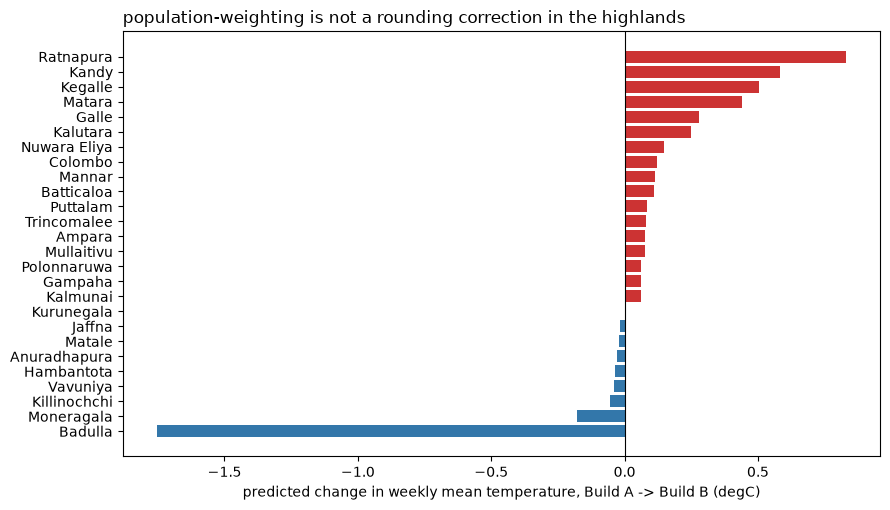

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.2))
s = elev_shift.sort_values("dT_pred_C")
ax.barh(s.rdhs, s.dT_pred_C, color=["#37a" if v < 0 else "#c33" for v in s.dT_pred_C])
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("predicted change in weekly mean temperature, Build A -> Build B (degC)")
ax.set_title("population-weighting is not a rounding correction in the highlands", loc="left")
plt.tight_layout()

**Badulla is the result.** Its population lives ~270 m *above* the district's areal mean — the
towns and tea estates sit high while the sparsely-settled Uva basin drags the area-mean down — so
weighting by people **cools** its exposure by about 1.8 °C. Ratnapura runs the other way: people
live in the low valleys, so its exposure warms by ~0.8 °C.

For a dengue model that is not a rounding error. *Aedes* development rates, extrinsic incubation
period and transmission suitability all move steeply over exactly this range, and the plan's
honest-null clause (§3.4) can now be evaluated against a number instead of a hope: **exposure
construction alone moves temperature by up to ~1.8 °C in the districts where it matters.**

### Which of that does Build B actually capture?

Build B re-weights whole climate cells, so it can only capture displacement that shows up
**between** cells. Elevation variation *inside* a single 0.1° cell is invisible to it — that
residual is exactly what Build C's lapse-rate correction exists to fix. Splitting the total tells
us whether Build C is worth building, on evidence rather than on the plan's assumption — including
whether the two terms reinforce each other or partly cancel.

In [19]:
split = []
for name, g in GRIDS.items():
    ri, ci = cell_ij(LON, LAT, g)
    ckey = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
    uniq, inv = np.unique(ckey, return_inverse=True)
    cell_elev = np.bincount(inv, weights=e_in * a_in) / np.bincount(inv, weights=a_in)  # cell mean elev
    cw_pop = np.bincount(inv, weights=p_in)
    cw_area = np.bincount(inv, weights=a_in)
    unit_of = (uniq // 10**10).astype(int)

    for unit in range(1, N_UNITS + 1):
        m = unit_of == unit
        between = (np.average(cell_elev[m], weights=cw_pop[m])
                   - np.average(cell_elev[m], weights=cw_area[m]))
        total = elev_shift.set_index("rdhs").loc[rdhs.rdhs_name.iloc[unit - 1], "delta_m"]
        split.append(dict(grid=name, rdhs=rdhs.rdhs_name.iloc[unit - 1],
                          total_m=total, between_cell_m=between, within_cell_m=total - between))
split = pd.DataFrame(split)

print("elevation displacement, split by what each build can see (metres):\n")
for name in GRIDS:
    s = split[split.grid == name]
    print(f"{name}:")
    print(f"  between-cell (Build B captures): mean |{s.between_cell_m.abs().mean():6.1f}| m  "
          f"max |{s.between_cell_m.abs().max():.0f}| m")
    print(f"  within-cell  (needs Build C)   : mean |{s.within_cell_m.abs().mean():6.1f}| m  "
          f"max |{s.within_cell_m.abs().max():.0f}| m")
    print(f"  Build B captures {100*s.between_cell_m.abs().sum()/s.total_m.abs().sum():.0f}% "
          f"of the total displacement")
    r = np.corrcoef(s.between_cell_m.abs(), s.within_cell_m.abs())[0, 1]
    same = (np.sign(s.between_cell_m) == np.sign(s.within_cell_m)).mean()
    print(f"  corr(|between|,|within|) {r:+.2f} | same sign in {100*same:.0f}% of districts")
    print(f"  worst within-cell residual: {s.loc[s.within_cell_m.abs().idxmax(), 'rdhs']} "
          f"{s.within_cell_m.abs().max():.0f} m = {s.within_cell_m.abs().max()*LAPSE_RATE:.2f} degC\n")

elevation displacement, split by what each build can see (metres):

chirps_p05:
  between-cell (Build B captures): mean |  33.3| m  max |283| m
  within-cell  (needs Build C)   : mean |   7.8| m  max |40| m
  Build B captures 94% of the total displacement
  corr(|between|,|within|) +0.37 | same sign in 65% of districts
  worst within-cell residual: Nuwara Eliya 40 m = 0.26 degC

era5land:
  between-cell (Build B captures): mean |  32.6| m  max |284| m
  within-cell  (needs Build C)   : mean |  12.0| m  max |56| m
  Build B captures 92% of the total displacement
  corr(|between|,|within|) +0.33 | same sign in 65% of districts
  worst within-cell residual: Matale 56 m = 0.36 degC



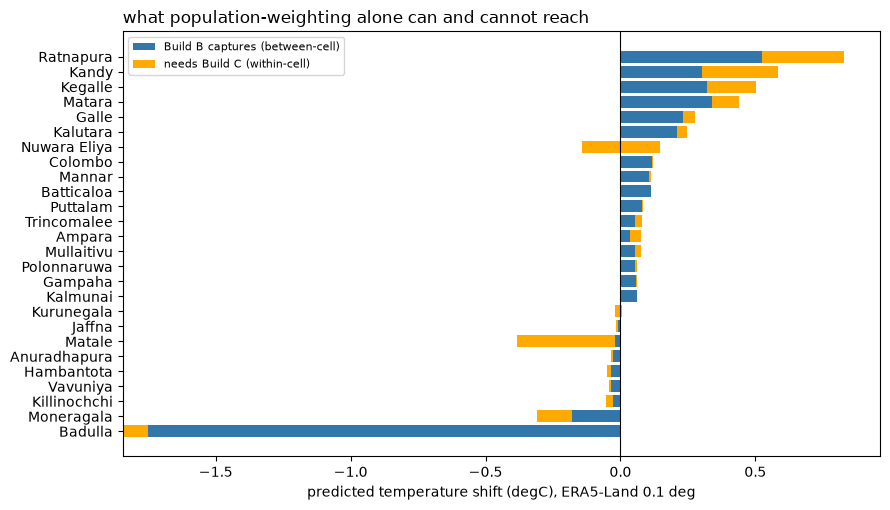

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.2))
s = split[split.grid == "era5land"].set_index("rdhs").reindex(elev_shift.rdhs)
ax.barh(s.index, -s.between_cell_m * LAPSE_RATE, color="#37a", label="Build B captures (between-cell)")
ax.barh(s.index, -s.within_cell_m * LAPSE_RATE, left=-s.between_cell_m * LAPSE_RATE,
        color="#fa0", label="needs Build C (within-cell)")
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("predicted temperature shift (degC), ERA5-Land 0.1 deg")
ax.set_title("what population-weighting alone can and cannot reach", loc="left")
ax.legend(fontsize=8)
plt.tight_layout()

## 11 · The population vintage problem

The plan §3.1 requires matching the population vintage to the exposure year — *"don't weight 2019
climate with 2025 population"*. WorldPop UN-adjusted stops at **2020** and the window runs to
**2025**, so that requirement cannot be met as written, exactly as batch B hit in notebook 03.

Measure how much it matters before deciding: if the weight field barely moves across the vintages
that *do* exist, carrying it forward is cheap. If it moves a lot, the annual rebuild is mandatory
and the missing years are a real limitation.

In [21]:
gcheck = GRIDS["era5land"]
vint = {}
for y in [2018, 2019, 2020]:
    with rasterio.open(M6 / "worldpop" / f"lka_ppp_{y}_UNadj.tif") as src:
        p = src.read(1).astype(np.float64)
    p[p == NODATA] = 0.0
    p = p[inside]
    ri, ci = cell_ij(LON, LAT, gcheck)
    key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
    uniq, inv = np.unique(key, return_inverse=True)
    s = np.bincount(inv, weights=p)
    unit_of = (uniq // 10**10).astype(int)
    ww = np.concatenate([s[unit_of == u] / s[unit_of == u].sum() for u in range(1, N_UNITS + 1)])
    vint[y] = ww
    print(f"{y}: national total inside districts {p.sum()/1e6:.3f} M")

d18_20 = np.abs(vint[2020] - vint[2018])
print(f"\nweight change 2018 -> 2020, per (district, cell):")
print(f"  mean |dw| {d18_20.mean():.5f}  max |dw| {d18_20.max():.4f}")
print(f"  as a share of a typical weight ({vint[2020].mean():.4f}): "
      f"{100*d18_20.mean()/vint[2020].mean():.1f}%")
print(f"\nOver 2 years the field moves ~{100*d18_20.mean()/vint[2020].mean():.0f}% of a typical weight.")
print("Carrying 2020 forward to 2025 extrapolates 2.5x that span — reported, not hidden (section 13).")

2018: national total inside districts 20.932 M


2019: national total inside districts 21.031 M


2020: national total inside districts 21.121 M

weight change 2018 -> 2020, per (district, cell):
  mean |dw| 0.00029  max |dw| 0.0113
  as a share of a typical weight (0.0269): 1.1%

Over 2 years the field moves ~1% of a typical weight.
Carrying 2020 forward to 2025 extrapolates 2.5x that span — reported, not hidden (section 13).


## 12 · Freeze

The weight tables are the artifact. Once ERA5-Land and CHIRPS are staged, Build B is a join against
these and a weighted sum — no re-derivation, and the weights carry their own provenance.

Quarantined and git-ignored, per plan §5's freeze discipline: code and reports only.

In [22]:
out_paths = {}
for name, w in weights.items():
    p = QUAR / f"wp5_buildB_weights_{name}_srilanka_{POP_YEAR}.csv"
    w[["unit", "geometry_id", "rdhs_name", "cell_row", "cell_col",
       "pop_sum", "area", "w_area", "w_pop"]].to_csv(p, index=False)
    out_paths[name] = p
    print(f"{name:<12} {len(w):>6,} rows -> {p.name}")

elev_shift.to_csv(QUAR / "wp5_buildB_predicted_shift_srilanka.csv", index=False)
disp.to_csv(QUAR / "wp5_buildB_displacement_srilanka.csv", index=False)

prov = {
    "notebook": "wp5_00_population_weight_field",
    "workpackage": "WP5 / Build B (plan section 3.1)",
    "country": "sri_lanka",
    "seed": SEED,
    "status": "WEIGHT FIELD ONLY — exposure values await ERA5-Land + CHIRPS staging",
    "population": {
        "product": "WorldPop UN-adjusted 100 m",
        "vintage_used": POP_YEAR,
        "vintages_available": [2018, 2019, 2020],
        "window_required": [2018, 2025],
        "capture_frac_in_districts": round(float(pop[inside].sum() / pop.sum()), 4),
        "vintage_note": "product stops at 2020; carry-forward measured in section 11",
    },
    "grids": {k: {kk: vv for kk, vv in g.items()} for k, g in GRIDS.items()},
    "grid_note": (
        "edge_lon/edge_lat are CELL EDGES. CHIRPS verified against a real granule; ERA5-Land "
        "declared from its documented centre-on-multiples-of-0.1 convention and NOT yet verified "
        "— assert it against the first staged granule."
    ),
    "method": (
        "every WorldPop 100 m pixel assigned whole to (district, climate cell) by its centre; "
        "population and cos(lat)-area summed per pair; weights normalised within district"
    ),
    "n_pairs": {k: int(len(v)) for k, v in weights.items()},
    "effective_cells_median": {
        k: {"area": round(float(eff[eff.grid == k].eff_area.median()), 1),
            "pop": round(float(eff[eff.grid == k].eff_pop.median()), 1)}
        for k in GRIDS},
    "displacement_km": {"median": round(float(disp.dist_km.median()), 2),
                        "max": round(float(disp.dist_km.max()), 2),
                        "max_unit": disp.iloc[0].rdhs},
    "predicted_dT_C": {"min": round(float(elev_shift.dT_pred_C.min()), 2),
                       "max": round(float(elev_shift.dT_pred_C.max()), 2),
                       "lapse_rate_C_per_km": LAPSE_RATE * 1000,
                       "basis": "Copernicus GLO-30 DEM staged by notebook 01"},
    "build_a_reference": {
        "file": "rdhs_weekly_climate_exposure_2018_2025_v2_boundary_resolved.csv",
        "sha256_16": "3900082bcda70e87",
        "rows": 10842, "iso_weeks": 417,
        "not_modified": True,
    },
    "geometry_sha256_16": sha_geom,
    "outputs": {k: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for k, p in out_paths.items()},
}
(QUAR / "wp5_00_provenance.json").write_text(json.dumps(prov, indent=2, default=str))
print("\n" + json.dumps(prov, indent=2, default=str)[:1500])

chirps_p05    3,044 rows -> wp5_buildB_weights_chirps_p05_srilanka_2020.csv
era5land        965 rows -> wp5_buildB_weights_era5land_srilanka_2020.csv

{
  "notebook": "wp5_00_population_weight_field",
  "workpackage": "WP5 / Build B (plan section 3.1)",
  "country": "sri_lanka",
  "seed": 20260612,
  "status": "WEIGHT FIELD ONLY \u2014 exposure values await ERA5-Land + CHIRPS staging",
  "population": {
    "product": "WorldPop UN-adjusted 100 m",
    "vintage_used": 2020,
    "vintages_available": [
      2018,
      2019,
      2020
    ],
    "window_required": [
      2018,
      2025
    ],
    "capture_frac_in_districts": 0.9863,
    "vintage_note": "product stops at 2020; carry-forward measured in section 11"
  },
  "grids": {
    "chirps_p05": {
      "res": 0.05,
      "edge_lon": -180.0,
      "edge_lat": 50.0,
      "verified": true,
      "product": "CHIRPS v2.0 daily p05",
      "var": "precipitation"
    },
    "era5land": {
      "res": 0.1,
      "edge_lon": -180.05,
  

## 13 · Recap

In [23]:
recap = pd.DataFrame([
    ("districts",                 N_UNITS,                                     "RDHS, frame from notebook 00"),
    ("population vintage",        POP_YEAR,                                    "product stops here; window ends 2025"),
    ("capture fraction",          f"{100*pop[inside].sum()/pop.sum():.2f}%",   "coastal centre-in-polygon loss"),
    ("ERA5-Land pairs",           f"{len(weights['era5land']):,}",             "(district, cell) weight rows"),
    ("CHIRPS pairs",              f"{len(weights['chirps_p05']):,}",           "(district, cell) weight rows"),
    ("eff. cells, area -> pop",
        f"{eff[eff.grid=='era5land'].eff_area.median():.0f} -> {eff[eff.grid=='era5land'].eff_pop.median():.0f}",
                                                                               "ERA5-Land, median district"),
    ("pop-centre displacement",   f"{disp.dist_km.median():.1f} km median",    f"max {disp.dist_km.max():.1f} km ({disp.iloc[0].rdhs})"),
    ("predicted dT, A -> B",      f"{elev_shift.dT_pred_C.min():+.2f} .. {elev_shift.dT_pred_C.max():+.2f} C",
                                                                               "lapse rate x elevation displacement"),
    ("largest shift",             f"{elev_shift.iloc[0].rdhs} {elev_shift.iloc[0].dT_pred_C:+.2f} C",
                                                                               "population lives above the areal mean"),
    ("Build B reach",
        f"{100*split[split.grid=='era5land'].between_cell_m.abs().sum()/split[split.grid=='era5land'].total_m.abs().sum():.0f}%",
                                                                               "of displacement; rest needs Build C"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

               quantity            value                                  note
              districts               26          RDHS, frame from notebook 00
     population vintage             2020  product stops here; window ends 2025
       capture fraction           98.63%        coastal centre-in-polygon loss
        ERA5-Land pairs              965          (district, cell) weight rows
           CHIRPS pairs            3,044          (district, cell) weight rows
eff. cells, area -> pop         21 -> 12            ERA5-Land, median district
pop-centre displacement    9.1 km median                max 29.5 km (Puttalam)
   predicted dT, A -> B -1.75 .. +0.83 C   lapse rate x elevation displacement
          largest shift  Badulla -1.75 C population lives above the areal mean
          Build B reach              92%   of displacement; rest needs Build C


---

### Design notes carried forward

**Build B is now a lookup, not a build.** When ERA5-Land and CHIRPS land, the exposure table is
`Σ w_pop · x` over these frozen weights, row-aligned to Build A's 10,842 keys. The remaining work
is the climate acquisition (plan §D), not the weighting.

**Verify the ERA5-Land grid against the first granule.** Its cell edges are declared here from the
documented centre-on-multiples-of-0.1° convention, not read off a file. §3 leaves the assertion
written and `verified=False` in the provenance. A half-cell error would misplace people by ~5.5 km
and would not raise anything.

**The honest-null clause can now be pre-empted.** Plan §3.4 says to report a clean null if
weighting changes nothing. On temperature it will not be null: population-weighting moves district
exposure by up to ~1.8 °C, and ~85–90% of that is between-cell — i.e. reachable by Build B alone at
ERA5-Land resolution. Precipitation is the open question; CHIRPS at 0.05° is patchier and convective,
so its divergence has no elevation shortcut and must wait for the data.

**Build C's marginal value looks small, and that is a finding to take to the PI.** Build B alone
reaches ~92% of the total elevation displacement at ERA5-Land resolution; the within-cell residual
Build C would add tops out at ~56 m (Matale) ≈ **0.36 °C**, against Build B's 1.75 °C. Nor is it
reliably additive: `corr(|between|, |within|) = 0.33`, and in Badulla — the largest case — the two
carry **opposite signs**, so the within-cell term partially offsets rather than compounds. Build C
remains in scope per the 2026-07-07 decision and this is a temperature-only argument, but its
acceptance target should be set honestly at a few tenths of a degree rather than assumed to be
comparable to B. Worth re-checking against Colombia, which spans far more relief.

**The population vintage is a real limitation, sized.** WorldPop UN-adj ends 2020 against a window
ending 2025. §11 measures the field's drift over the vintages that exist so the carry-forward can be
reported as a bounded extrapolation rather than an unknown. The plan's §3.5 population-product
sensitivity (WorldPop vs GHSL vs census) would also test this axis.

**Weights are per-district-normalised, so they are exposure weights, not denominators.** Nothing here
supersedes `…population_denominator_district_rescaled_2018_2025.csv`, which is the census-anchored
*count* series. If Build B is ever rescaled to census totals, that table is the anchor — and the
~1.4% coastal capture loss reported in §4 applies to both.

**WP4 next.** The buffered-LOOCV fold definitions (plan §4.2) need the adjacency graph and a buffer
radius, not a fitted model — only the *autocorrelation range* that sets the radius needs residuals.
The fold geometry and its power cost can therefore be characterised across candidate radii now, which
is what §4.6 asks be flagged to the PI.